In [1]:
import pandas as pd
import proteopy as pr

adata = pr.datasets.williams_2018()

# Filter
mask = adata.var["protein_id"].isin(["iRT_protein", "A2ASS6"])
adata = adata[:, ~mask]

# Save to tsvs
df_x = pd.DataFrame(
    adata.X,
    index=adata.obs_names,
    columns=adata.var_names,
)
df_x.index.name = "sample_id"
df_long = df_x.reset_index().melt(
    id_vars="sample_id",
    var_name="peptide_id",
    value_name="intensity",
)
df_long.to_csv("data/intensities.tsv", sep="\t", index=False)

adata.var[["peptide_id", "protein_id", "gene_id"]].to_csv(
    "data/peptide_annotation.tsv", sep="\t", index=False
)

adata.obs[["sample_id", "tissue", "mouse_id"]].to_csv(
    "data/sample_annotation.tsv", sep="\t", index=False
)

In [2]:
import proteopy as pr

adata = pr.read.long(
    intensities="data/intensities.tsv",
    sample_annotation="data/sample_annotation.tsv",
    var_annotation="data/peptide_annotation.tsv",
    level="peptide",
    sep="\t",
    fill_na=0,
)

pr.pp.summarize_modifications(adata, method="sum")
pr.pp.summarize_overlapping_peptides(adata)

pr.pp.filter_proteins_by_peptide_count(adata, min_count=4)
pr.pp.remove_zero_variance_vars(adata)

pr.tl.pairwise_peptide_correlations(adata)
pr.tl.peptide_dendograms_by_correlation(adata)
pr.tl.peptide_clusters_from_dendograms(adata)
pr.tl.proteoform_scores(adata)

Removed 1770 proteins and 2984 peptides.


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


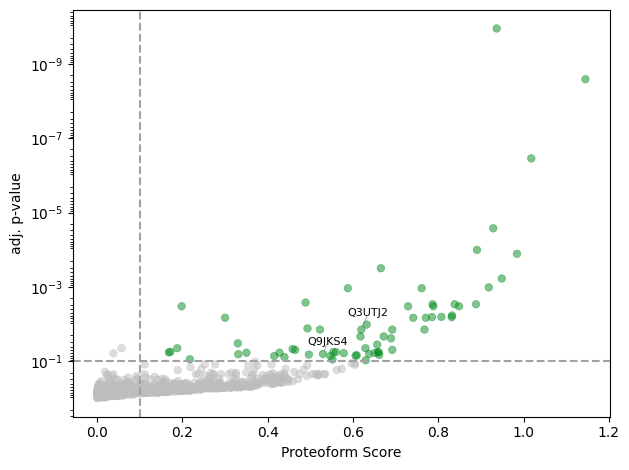

<Axes: xlabel='Proteoform Score', ylabel='adj. p-value'>

In [3]:
pr.pl.proteoform_scores(
    adata,
    pval_threshold=0.1,
    score_threshold=0.1,
    adj=True,
    highlight_prots=["Q9JKS4", "Q3UTJ2"],
)

<Axes: xlabel='Proteoform Score', ylabel='adj. p-value'>

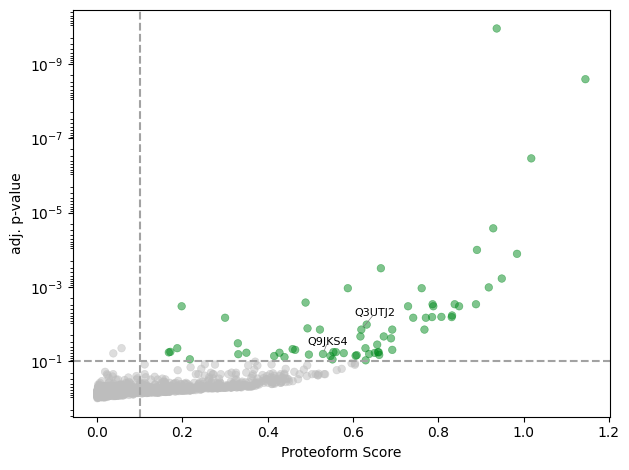

In [4]:
pr.pl.proteoform_scores(
    adata,
    pval_threshold=0.1,
    score_threshold=0.1,
    adj=True,
    highlight_prots=["Q9JKS4", "Q3UTJ2"],
    show=False,
    save="figure-1-B.png",
)